In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from create_system_matrix import load_H_matrix, create_system_matrices, matrix_to_sparse_csv

from scipy.linalg import eig
from matplotlib.scale import SymmetricalLogTransform

In [2]:
#%% PLOT SETTINGS
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'lines.linewidth': 2,
    'lines.markersize': 6,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'grid.alpha': 0.3,
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'figure.dpi': 150,
    'axes.facecolor': '#F1F5F2',
    'axes.grid': True
})

colors = plt.get_cmap('tab10').colors
#turn colors into a list
colors = [colors[i] for i in range(len(colors))]
colors = ['#EFA00B', '#439775', '#4B4E6D', '#6A4C93', '#FAC8CD', '#9BC1BC', '#5D737E', '#D9BF77', '#ACD8AA', '#FFE156']

In [3]:
#set discrepancy tolerance
tol = 0.003

## **Standard Bat**

In [4]:
H_alan = load_H_matrix('data/matrices/H_matrix_Alan.csv')

In [5]:
# edge case ij, ji, all of jj
# 
mass = 0.885 # in kg
rho = 649 # in kg/m^3

Y = 1.814 * 1e10  # convert to N/m^2
S = 1.05 * 1e9 # convert to N/m^2
N = 84  # number of slices
dz = 0.84 / N # slice thickness in m

# load bat profile
bat_prof = np.loadtxt('data/bats/r161.dat')
bat_prof[:, 1] = bat_prof[:, 1] / 2 # convert diameter to radius
Ai = np.pi * (bat_prof[:, 1] * 1e-3)**2  # in m^2
Vi = Ai * dz  # in m^3
Ii = np.pi/4 * (bat_prof[:, 1] * 1e-3)**4  # in m^4

Lam = S / (rho * dz**2)
Ups = Y / (rho * dz**2)
H_nava = create_system_matrices(N, Ai, Ii, dz, S, Y, rho, path='data/matrices/H_matrix_nava.csv')

In [6]:
#eigenvals nava
evalsN, evecsN = np.linalg.eig(H_nava)
omegaN = np.sqrt(np.abs(evalsN))
freqsN = omegaN / (2 * np.pi)
freqsN.sort()
print(freqsN[:10])

[8.71642105e-04 9.99849494e-04 1.72387848e+02 5.74293413e+02
 1.17863488e+03 1.84702809e+03 2.57747080e+03 3.35896846e+03
 4.16323413e+03 4.97410137e+03]


### **Find Largest Disrepencies**

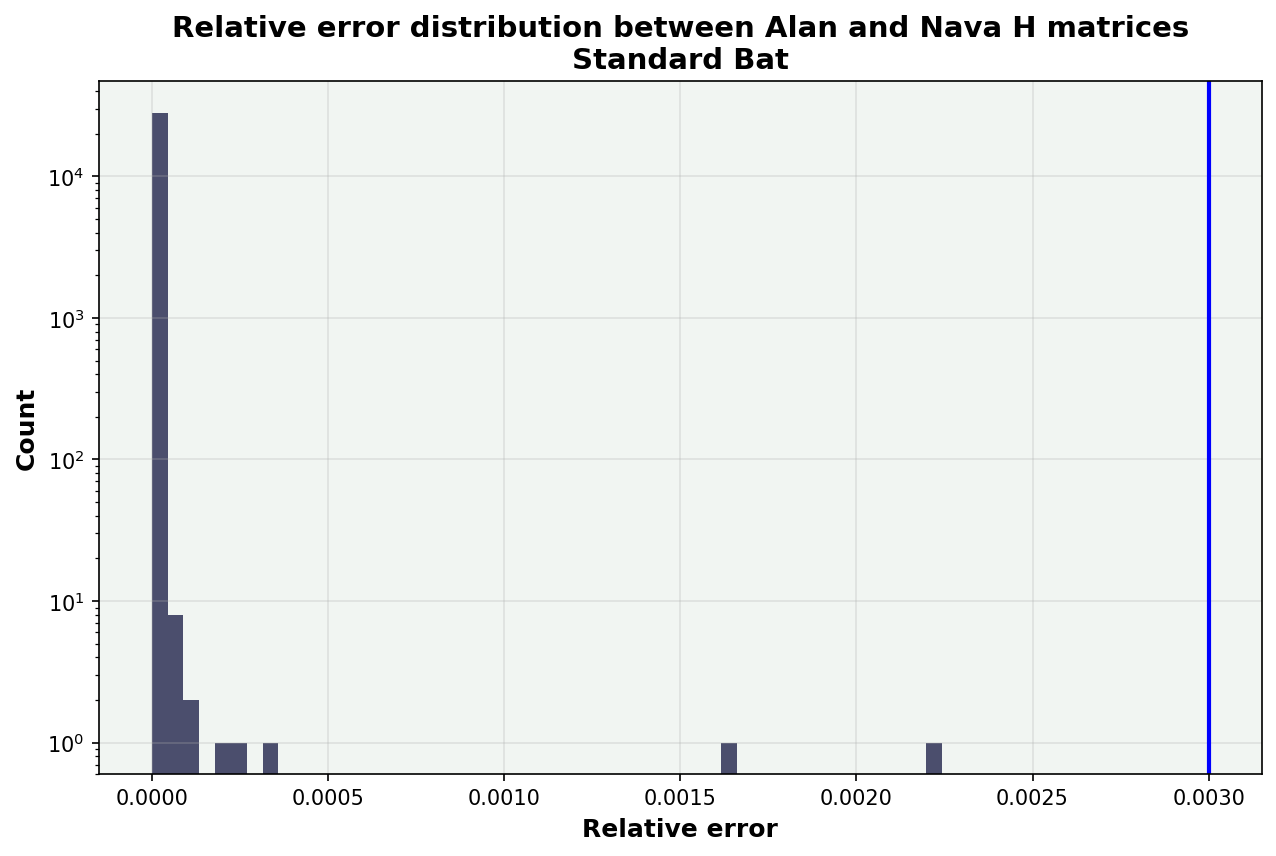

In [7]:
#rel error
rel_error = np.abs(H_alan - H_nava) / (np.abs(H_alan) + 1e-10)
#histogram
plt.hist(rel_error.flatten(), bins = 50, color = colors[2])
plt.xlabel('Relative error')
plt.axvline(x = tol, color = 'blue', label = f'{tol} threshold')
plt.ylabel('Count')
plt.yscale('log')
plt.title('Relative error distribution between Alan and Nava H matrices\nStandard Bat')
plt.show()

In [8]:
# high error
high_error_idxs = np.where(rel_error > tol)
discrepancy_df = pd.DataFrame({
    'Row': high_error_idxs[0] + 1,  # add 1 to convert from 0-indexed to 1-indexed
    'Col': high_error_idxs[1] + 1,  # add 1 to convert from 0-indexed to 1-indexed
    'Quandrant': np.where((high_error_idxs[0] < N) & (high_error_idxs[1] < N), '1',
                 np.where((high_error_idxs[0] < N) & (high_error_idxs[1] >= N), '2',
                 np.where((high_error_idxs[0] >= N) & (high_error_idxs[1] < N), '3', '4'))),
    'Alan Value': H_alan[high_error_idxs],
    'Nava Value': H_nava[high_error_idxs],
    'Relative Error': rel_error[high_error_idxs]
})
discrepancy_df

,Row,Col,Quandrant,Alan Value,Nava Value,Relative Error


In [24]:
mass = 0.885 # in kg
rho = 649 # in kg/m^3

Y = 1.814 * 1e10  # convert to N/m^2
S = 1.05 * 1e9 # convert to N/m^2
N = 84  # number of slices
dz = 0.84 / N # slice thickness in m

# load bat profile
bat_prof = np.loadtxt('data/bats/r161.dat')
bat_prof[:, 1] = bat_prof[:, 1] / 2 # convert diameter to radius
Ai = np.pi * (bat_prof[:, 1] * 1e-3)**2  # in m^2
Vi = Ai * dz  # in m^3
Ii = np.pi/4 * (bat_prof[:, 1] * 1e-3)**4  # in m^4

Lam = S / (rho * dz**2)
Ups = Y / (rho * dz**2)
H_nava = create_system_matrices(N, Ai, Ii, dz, S, Y, rho)
from bat_class import BatOsc, bat_from_json
torp = bat_from_json('data/bats/torpedo_bat_params.json')
torp.get_H_matrix()
H_torp = torp.H

<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
/var/folders/9b/gcnbw5016f10hn50pnxmd2t40000gn/T/ipykernel_30934/2679808110.py:34: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel('Eigenvalues of $\mathrm{{H}}$\nStandard Bat')


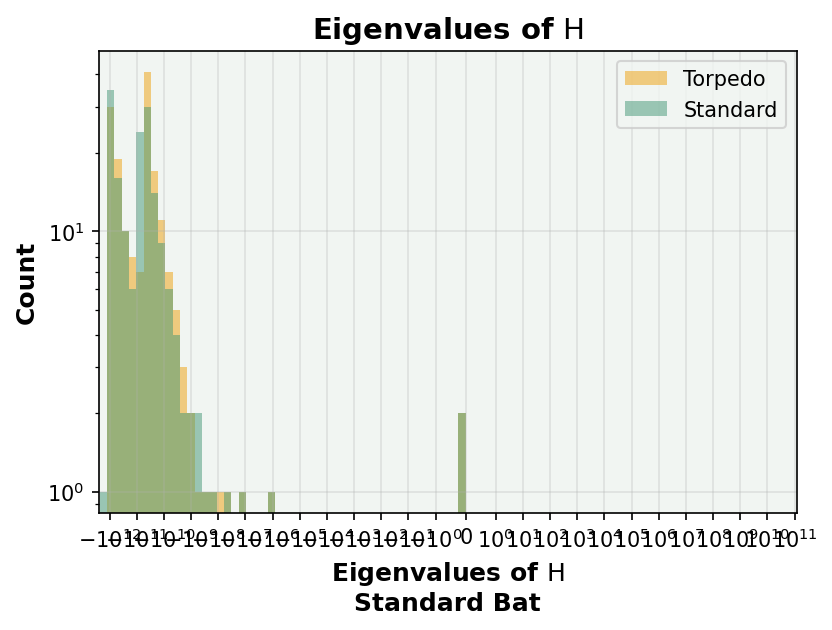

[2.9994121e-05]
max real eig: 2.999412098046504e-05


In [31]:
# Compute eigenvalues for both matrices
evals_alan = np.linalg.eig(H_torp)[0]
evals_nava = np.linalg.eig(H_nava)[0]

def symlog_bins(data_list, nbins=50, linthresh=1.0):
    """Create bins that are evenly spaced in symlog-transformed coordinates."""
    all_data = np.concatenate(data_list)
    fwd = SymmetricalLogTransform(base=10, linthresh=linthresh, linscale=1)
    inv = fwd.inverted()
    transformed = fwd.transform_non_affine(all_data)
    t_bins = np.linspace(transformed.min(), transformed.max(), nbins + 1)
    return inv.transform_non_affine(t_bins)

#%% IS thIS JUST DIAGONALIZATION ERROR?

# --- Real part histogram ---
real_alan = evals_alan.real
real_nava = evals_nava.real
real_alan_nz = real_alan[real_alan != 0]
real_nava_nz = real_nava[real_nava != 0]

all_real = np.concatenate([real_alan_nz, real_nava_nz])
# r_linthresh = np.min(np.abs(all_real[all_real != 0]))
r_linthresh = 1
rbins = symlog_bins([real_alan_nz, real_nava_nz], nbins=50, linthresh=r_linthresh)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(real_alan_nz, bins=rbins, alpha=0.5, label='Torpedo', color=colors[0])
ax.hist(real_nava_nz, bins=rbins, alpha=0.5, label='Standard', color=colors[1])
ax.set_title(r'Eigenvalues of $\mathrm{H}$')
ax.set_ylabel('Count')
ax.set_yscale('log')
ax.set_xscale('symlog', linthresh=r_linthresh)
ax.set_xlabel('Eigenvalues of $\mathrm{{H}}$\nStandard Bat')
ax.legend()
plt.show()
print(np.sort(evals_nava.real[evals_nava.real > 0]))
print("max real eig:", evals_nava.real.max())

In [42]:
omegasN = np.sqrt(-evals_nava) / (2 * np.pi)
omegasN.sort()
for i in range(10):
    print(f"Mode {i+1}: {omegasN[i]:.2f} Hz")

Mode 1: 0.00 Hz
Mode 2: 172.39 Hz
Mode 3: 574.29 Hz
Mode 4: 1178.63 Hz
Mode 5: 1847.03 Hz
Mode 6: 2577.47 Hz
Mode 7: 3358.97 Hz
Mode 8: 4163.23 Hz
Mode 9: 4974.10 Hz
Mode 10: 5793.98 Hz


/var/folders/9b/gcnbw5016f10hn50pnxmd2t40000gn/T/ipykernel_61526/1582210494.py:1: RuntimeWarning: invalid value encountered in sqrt
  omegasN = np.sqrt(-evals_nava) / (2 * np.pi)


In [45]:
#save my matrix
matrix_to_sparse_csv(H_nava, 'data/H_matrix_nava.csv')
H_nava2 = load_H_matrix('data/H_matrix_nava.csv')
#make sure they are the same
assert np.allclose(H_nava, H_nava2), "Loaded matrix does not match original"

In [46]:
# are any eigvals with positive real part? If so, how many?
H_eig = np.linalg.eig(H_nava)
H_eigvals = H_eig[0]
num_unstable = np.sum(H_eigvals.real > 0)
print(f'Number of eigenvalues with positive real part: {num_unstable}')
for num in range(num_unstable):
    print(f'Unstable eigenvalue {num+1}: {H_eigvals[H_eigvals.real > 0][num]:.2e}')

Number of eigenvalues with positive real part: 1
Unstable eigenvalue 1: 3.00e-05


## **Torpedo**

Now Compare for Torpedo

In [ ]:
N = 85

Y = 1.65 * 1e10  # convert to N/m^2
S = 0.9 * 1e9 # convert to N/m^2
dz = 0.85 / N # slice thickness in m
rho = 690 #in kg/m

# load bat profile
bat_prof = np.loadtxt('data/bats/torpedo.dat')
bat_prof[:, 1] = bat_prof[:, 1] / 2 # convert diameter to radius
Ai = np.pi * (bat_prof[:, 1] * 1e-3)**2  # in m^2
Vi = Ai * dz  # in m^3
Ii = np.pi/4 * (bat_prof[:, 1] * 1e-3)**4  # in m^4

Lam = S / (rho * dz**2)
Ups = Y / (rho * dz**2)

H_navaT = create_system_matrices(N, Ai, Ii, dz, S, Y, rho, path='data/matrices/H_matrix_nava_torpedo.csv')
H_alanT = load_H_matrix('data/matrices/H_matrix_torpedo.csv', N)

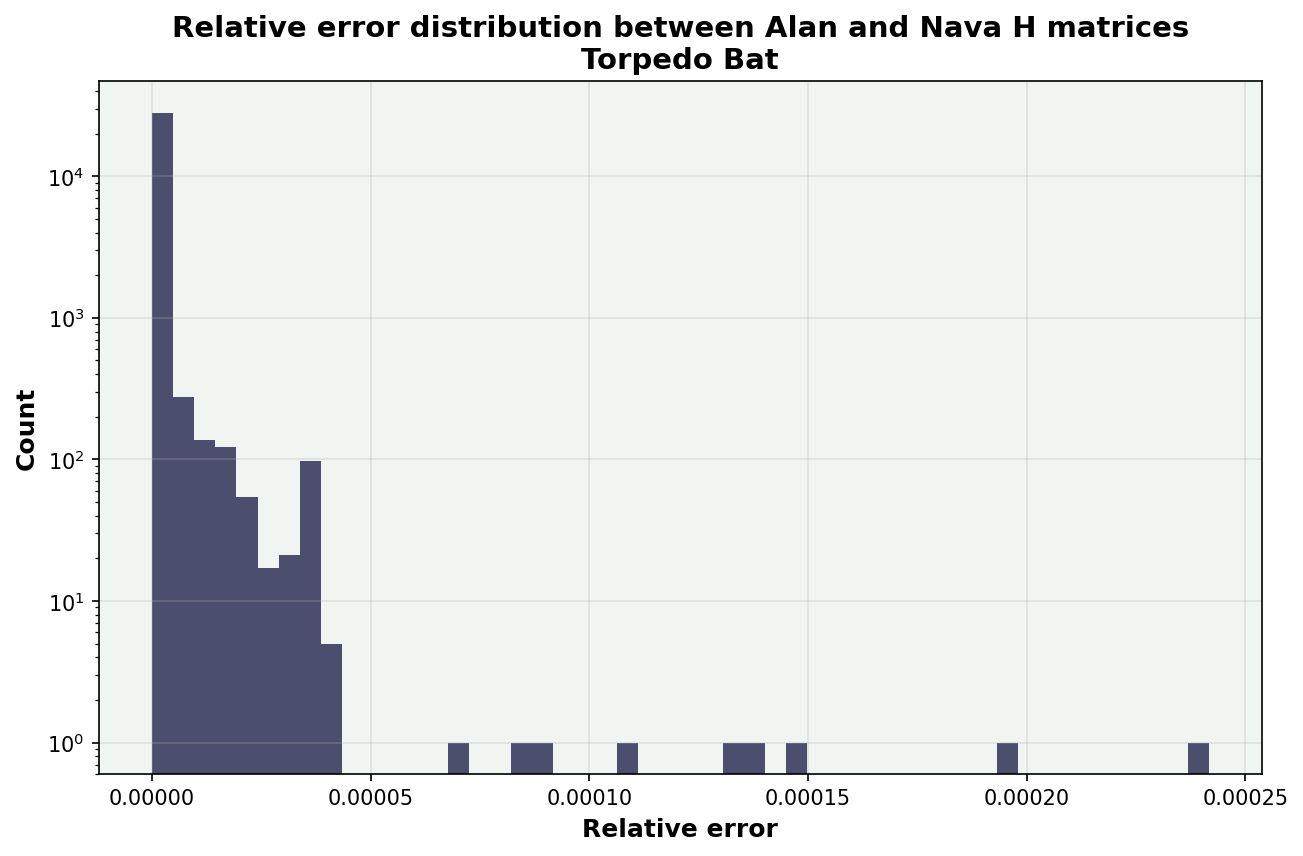

In [56]:
#rel error
rel_error = np.abs(H_alanT - H_navaT) / (np.abs(H_alanT) + 1e-10)
plt.hist(rel_error.flatten(), bins = 50, color = colors[2])
plt.xlabel('Relative error')
plt.ylabel('Count')
plt.yscale('log')
plt.title('Relative error distribution between Alan and Nava H matrices\nTorpedo Bat')
plt.show()

In [57]:
# high error
high_error_idxs = np.where(rel_error > tol)
discrepancy_dfT = pd.DataFrame({
    'Row': high_error_idxs[0] + 1,  # add 1 to convert from 0-indexed to 1-indexed
    'Col': high_error_idxs[1] + 1,  # add 1 to convert from 0-indexed to 1-indexed
    'Quadrant': np.where((high_error_idxs[0] < N) & (high_error_idxs[1] < N), '1',
                 np.where((high_error_idxs[0] < N) & (high_error_idxs[1] >= N), '2',
                 np.where((high_error_idxs[0] >= N) & (high_error_idxs[1] < N), '3', '4'))),
    'Alan Value': H_alanT[high_error_idxs],
    'Nava Value': H_navaT[high_error_idxs],
    'Relative Error': rel_error[high_error_idxs]
})
discrepancy_dfT

,Row,Col,Quadrant,Alan Value,Nava Value,Relative Error


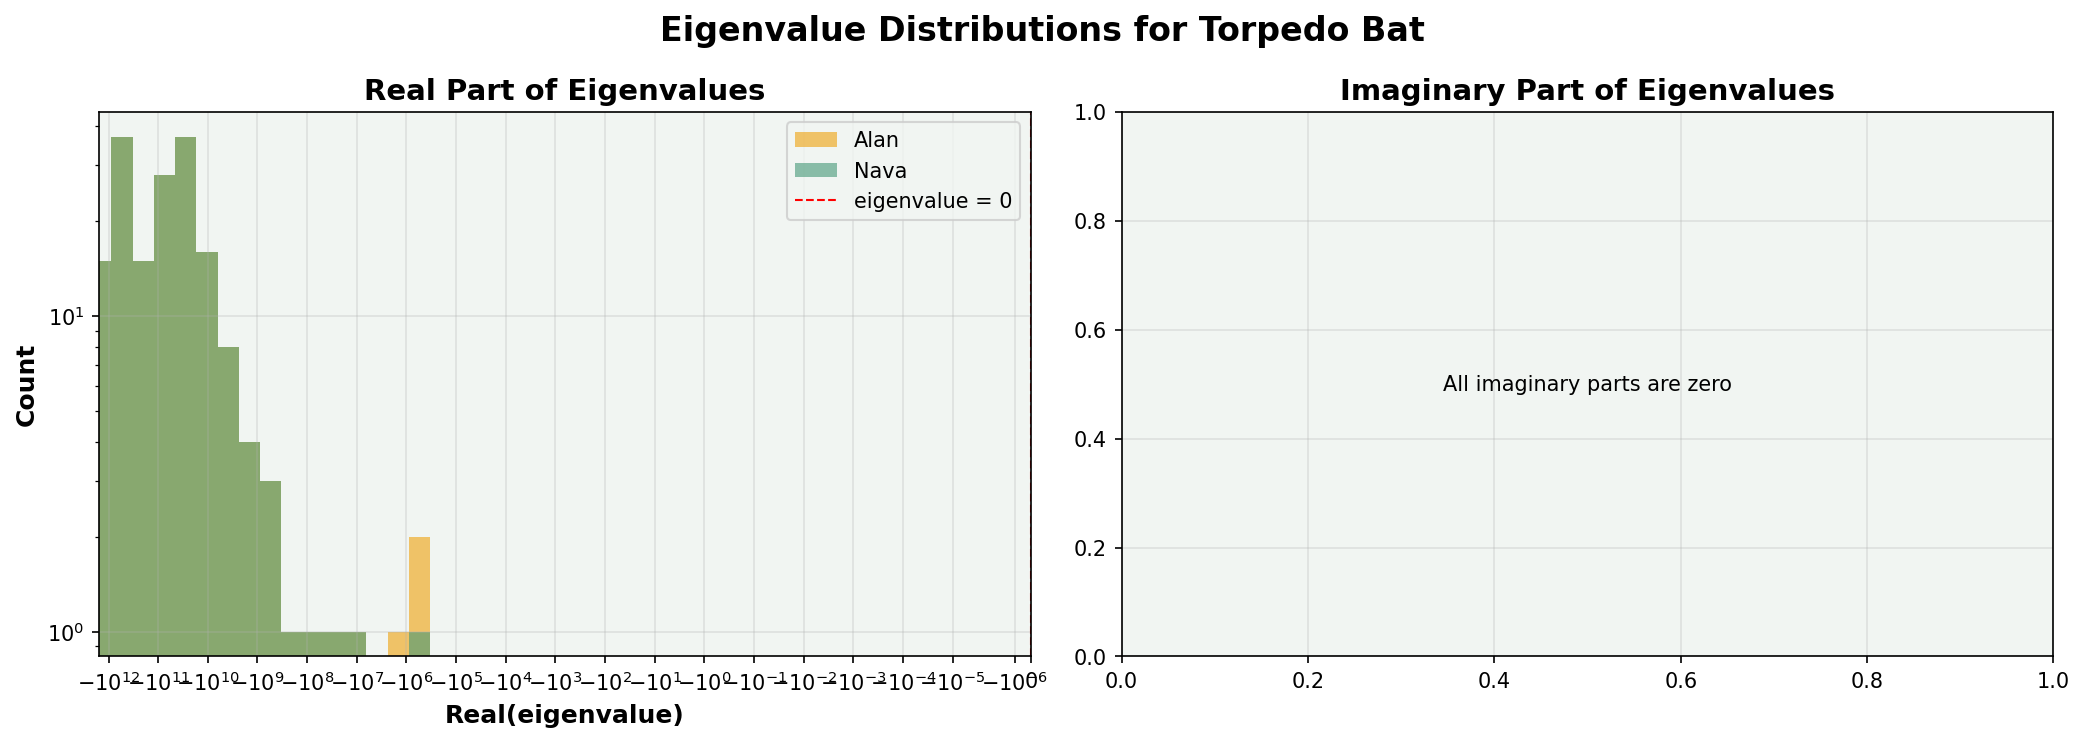

In [59]:
# Compute eigenvalues for both matrices
evals_alan = np.linalg.eig(H_alanT)[0]
evals_nava = np.linalg.eig(H_navaT)[0]

def robust_auto_xlim(data, q_low=0.005, q_high=0.995):
    data = np.asarray(data)
    if data.size == 0:
        return -1.0, 1.0

    lo, hi = np.quantile(data, [q_low, q_high])
    lo = min(lo, 0.0)
    hi = max(hi, 0.0)

    if np.isfinite(lo) and np.isfinite(hi) and lo < hi:
        return float(lo), float(hi)

    dmin, dmax = float(np.min(data)), float(np.max(data))
    if dmin == dmax:
        delta = max(abs(dmin) * 0.05, 1.0)
        return dmin - delta, dmax + delta
    return dmin, dmax

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Real part histogram ---
real_alan = evals_alan.real
real_nava = evals_nava.real
real_alan_nz = real_alan[real_alan != 0]
real_nava_nz = real_nava[real_nava != 0]

all_real = np.concatenate([real_alan_nz, real_nava_nz])
r_linthresh = np.min(np.abs(all_real[all_real != 0]))
rbins = symlog_bins([real_alan_nz, real_nava_nz], nbins=50, linthresh=r_linthresh)

axes[0].hist(real_alan_nz, bins=rbins, alpha=0.6, label='Alan', color = colors[0])
axes[0].hist(real_nava_nz, bins=rbins, alpha=0.6, label='Nava', color = colors[1])
axes[0].set_xscale('symlog', linthresh=r_linthresh)
axes[0].set_xlim(*robust_auto_xlim(all_real))
axes[0].set_yscale('log')
axes[0].axvline(x=0, color='r', linestyle='--', linewidth=1, label='eigenvalue = 0')
axes[0].set_xlabel('Real(eigenvalue)')
axes[0].set_ylabel('Count')
axes[0].set_title('Real Part of Eigenvalues')
axes[0].legend()

# --- Imaginary part histogram ---
imag_alan = evals_alan.imag
imag_nava = evals_nava.imag
imag_alan_nz = imag_alan[imag_alan != 0]
imag_nava_nz = imag_nava[imag_nava != 0]

imag_all_nz = np.concatenate([imag_alan_nz, imag_nava_nz])
if len(imag_all_nz) > 0:
    i_linthresh = np.min(np.abs(imag_all_nz[imag_all_nz != 0]))
    ibins = symlog_bins([imag_all_nz], nbins=50, linthresh=i_linthresh)

    if len(imag_alan_nz) > 0:
        axes[1].hist(imag_alan_nz, bins=ibins, alpha=0.6, label='Alan', color = colors[0])
    else:
        axes[1].hist([],alpha = 0.6, label='Alan (all zero)', color = colors[0])
    if len(imag_nava_nz) > 0:
        axes[1].hist(imag_nava_nz, bins=ibins, alpha=0.6, label='Nava', color=colors[1])
    else:
        axes[1].hist([], alpha = 0.6, label='Nava (all zero)', color = colors[1])

    axes[1].set_xscale('symlog', linthresh=i_linthresh)
    axes[1].set_xlim(*robust_auto_xlim(imag_all_nz))
    axes[1].set_yscale('log')
    axes[1].axvline(x=0, color='r', linestyle='--', linewidth=1, label='eigenvalue = 0')
    axes[1].set_xlabel('Imag(eigenvalue)')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Imaginary Part of Eigenvalues')
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, 'All imaginary parts are zero',
                 transform=axes[1].transAxes, ha='center', va='center')
    axes[1].set_title('Imaginary Part of Eigenvalues')
plt.suptitle('Eigenvalue Distributions for Torpedo Bat', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Look at both 

In [60]:
discrepancy_df.rename(columns={'Quandrant': 'Quadrant'}, inplace=True)
discrepancy_dfT['bat'] = 'T'
discrepancy_df['bat'] = 'S'
disc_df = pd.concat([discrepancy_df, discrepancy_dfT], ignore_index=True)
disc_df['N'] = disc_df['bat'].apply(lambda bat: 84 if bat == 'S' else 85)


In [61]:
quad_guide = {'1': ['i', 'i'], '2': ['i', 'j'], '3': ['j', 'i'], '4': ['j', 'j']}
idx_notes = []

for i, row in disc_df.iterrows():
    r = row['Row'] % row['N']
    c = row['Col'] % row['N']
    diff = c-r
    quad = quad_guide[row['Quadrant']]
    if diff > 0:
        sgn = '+'
    elif diff < 0:
        sgn = '-'
    if diff!= 0:
        idx_notes.append(f"H_{{{quad[0]}, {quad[1]} {sgn} {abs(diff)}}}")
    else:
        idx_notes.append(f"H_{{{quad[0]}, {quad[1]}}}")
disc_df['idx_notes'] = idx_notes


In [62]:
disc_df

,Row,Col,Quadrant,Alan Value,Nava Value,Relative Error,bat,N,idx_notes


## **Plots**

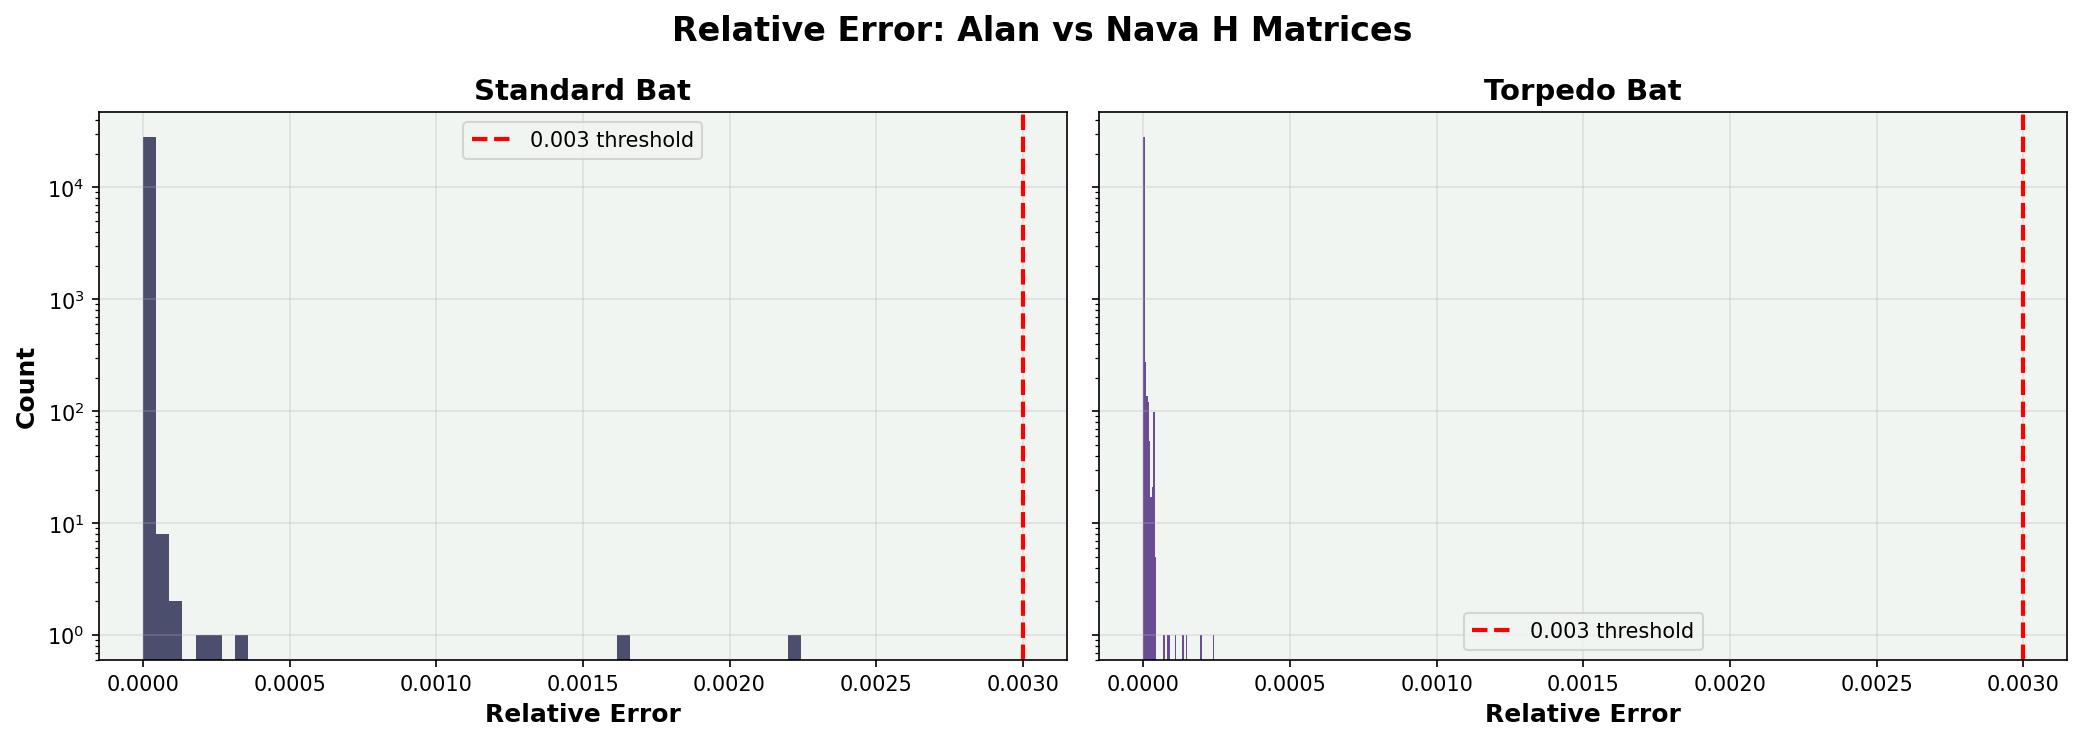

In [54]:
# Relative error side-by-side: Standard vs Torpedo
rel_error_S = np.abs(H_alan - H_nava) / (np.abs(H_alan) + 1e-10)
rel_error_T = np.abs(H_alanT - H_navaT) / (np.abs(H_alanT) + 1e-10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

ax1.hist(rel_error_S.flatten(), bins=50, color=colors[2])
ax1.axvline(x=tol, color='red', linestyle='--', label=f'{tol} threshold')
ax1.set_xlabel('Relative Error')
ax1.set_ylabel('Count')
ax1.set_yscale('log')
ax1.set_title('Standard Bat')
ax1.legend()

ax2.hist(rel_error_T.flatten(), bins=50, color=colors[3])
ax2.axvline(x=tol, color='red', linestyle='--', label=f'{tol} threshold')
ax2.set_xlabel('Relative Error')
ax2.set_yscale('log')
ax2.set_title('Torpedo Bat')
ax2.legend()

fig.suptitle('Relative Error: Alan vs Nava H Matrices', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('midterm_report/plots/rel_error.pdf')
plt.show()

In [55]:
disc_df.to_csv('midterm_report/err.csv')

In [32]:
0.01 / 10000

1e-06